# Deribit BTC options — implied volatility smile

This notebook builds a daily, short-dated BTC implied-volatility smile from raw
Deribit trades and compares it directly to the smile recovered from Polymarket's
range markets (see `polymarket_analysis.ipynb`).

**Steps**

1. Load `data/deribit_full.parquet` (≈ 4.3 M trades, Nov 2025–).
2. Parse the `instrument_name` (`BTC-2NOV25-113000-C`) into expiry / strike /
   option type and compute time-to-expiry.
3. Filter to **daily-expiring** options (trades happening in the 24 h before
   expiry) so the maturity matches Polymarket's daily resolution.
4. Bucket trades into time-to-expiry windows matching the extended Polymarket
   lookback: six 4-hour fine bins `[0,4)…[20,24)` h plus four day-scale coarse
   bins `[24,48)`, `[48,72)`, `[72,120)`, `[120,168)` h.
5. Aggregate trade-level IV by `(bucket, log-moneyness bin)`.
6. Overlay the two smiles side-by-side.


In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

DERIBIT_PARQUET = Path("data/deribit_full.parquet")
POLY_SMILE_PARQUET = Path("01 Data Extraction/Data/BTC Reach Daily Combined/polymarket_smile.parquet")

print(f"Deribit file: {DERIBIT_PARQUET}  ({DERIBIT_PARQUET.stat().st_size/1e6:.1f} MB)")
print(f"Polymarket smile parquet: {POLY_SMILE_PARQUET}")


Deribit file: data/deribit_full.parquet  (74.0 MB)
Polymarket smile parquet: 01 Data Extraction/Data/BTC Reach Daily Combined/polymarket_smile.parquet


## 1. Load and parse the Deribit trade tape

We keep only the columns we need: trade time, instrument name, traded IV,
underlying index price.  The `instrument_name` follows the format
`BTC-DDMMMYY-STRIKE-C` or `…-P`.  Daily-expiring BTC options on Deribit settle
at **08:00 UTC** on the expiry date — we use this to compute the time-to-expiry
of each trade.


In [2]:
RAW_COLS = ["timestamp", "instrument_name", "iv", "index_price", "mark_price", "amount"]
raw = pd.read_parquet(DERIBIT_PARQUET, columns=RAW_COLS)
print(f"Loaded {len(raw):,} trades, {raw['timestamp'].min()}  ->  {raw['timestamp'].max()}")

# Keep only BTC option trades with non-zero IV / index
btc_mask = raw["instrument_name"].str.startswith("BTC-")
raw = raw[btc_mask & raw["iv"].notna() & (raw["iv"] > 0) & (raw["index_price"] > 0)].copy()
print(f"After BTC + valid IV filter: {len(raw):,} trades")

# Parse instrument name:  BTC-2NOV25-113000-C  ->  (expiry_date, strike, type)
INSTR_RE = re.compile(r"^BTC-(\d{1,2})([A-Z]{3})(\d{2})-(\d+)-([CP])$")
MONTHS = {"JAN":1, "FEB":2, "MAR":3, "APR":4, "MAY":5, "JUN":6,
          "JUL":7, "AUG":8, "SEP":9, "OCT":10, "NOV":11, "DEC":12}

def parse_instrument(name):
    m = INSTR_RE.match(name)
    if not m:
        return pd.NA, pd.NA, pd.NA
    d, mon, yy, strike, typ = m.groups()
    return (pd.Timestamp(2000 + int(yy), MONTHS[mon], int(d)), int(strike), typ)

# Vectorised parse via unique names (massive speed-up: ~1k unique names vs 4M rows)
uniq = raw["instrument_name"].drop_duplicates().to_frame()
uniq[["expiry_date", "strike", "opt_type"]] = uniq["instrument_name"].apply(
    lambda x: pd.Series(parse_instrument(x))
)
uniq = uniq.dropna(subset=["expiry_date", "strike", "opt_type"])
print(f"Parsed {len(uniq):,} unique instruments")

raw = raw.merge(uniq, on="instrument_name", how="inner")
# Expiry datetime: 08:00 UTC on the expiry date (Deribit convention)
raw["expiry_dt"] = raw["expiry_date"].dt.tz_localize("UTC") + pd.Timedelta(hours=8)
raw["ttr_h"] = (raw["expiry_dt"] - raw["timestamp"].dt.tz_localize("UTC")).dt.total_seconds() / 3600.0
raw["log_moneyness"] = np.log(raw["strike"] / raw["index_price"])
raw["iv_frac"] = raw["iv"] / 100.0   # Deribit reports IV in percent

print(f"\nttr_h distribution: min={raw['ttr_h'].min():.1f}  p25={raw['ttr_h'].quantile(0.25):.1f}  "
      f"p50={raw['ttr_h'].median():.1f}  p75={raw['ttr_h'].quantile(0.75):.1f}  max={raw['ttr_h'].max():.1f}")
raw.head(3)


Loaded 4,262,530 trades, 2025-11-01 00:00:03.062000  ->  2026-05-19 08:59:59.103000


After BTC + valid IV filter: 4,247,228 trades


Parsed 8,368 unique instruments



ttr_h distribution: min=0.0  p25=30.4  p50=133.9  p75=682.4  max=8759.9


,timestamp,instrument_name,iv,index_price,mark_price,amount,expiry_date,strike,opt_type,expiry_dt,ttr_h,log_moneyness,iv_frac
0,2025-11-01 00:00:03.062,BTC-2NOV25-113000-C,24.32,109558.83,1.195800e-04,0.5,2025-11-02,113000,C,2025-11-02 08:00:00+00:00,31.999149,0.030926,0.2432
1,2025-11-01 00:00:09.822,BTC-14NOV25-106000-P,41.80,109566.05,1.651399e-02,0.3,2025-11-14,106000,P,2025-11-14 08:00:00+00:00,319.997272,-0.033088,0.4180
2,2025-11-01 00:00:17.784,BTC-1NOV25-117000-C,93.35,109573.92,1.700000e-07,0.1,2025-11-01,117000,C,2025-11-01 08:00:00+00:00,7.995060,0.065575,0.9335


## 2. Filter to daily-expiring options and bucket by time-to-expiry

We keep trades with `0 ≤ ttr ≤ 168 h`, matching the full market lifetime of
Polymarket's daily range markets (markets are open ~7 days before resolution).
This extended window lets us compare the two markets' IV term structure well
beyond the final 24 h.
We then bucket each trade into one of six 4-hour windows.

We also apply mild filters that mirror good practice for short-dated options:

* drop trades with IV ≥ 500% (data errors / illiquid prints),
* drop trades with `|log_moneyness| > 0.05` (~ ±5% strikes), matching the
  Polymarket band range.


In [3]:
# Six 4-h fine bins (last 24 h) + four coarse day-scale bins (24–168 h),
# matching the extended lookback in polymarket_analysis.ipynb (section 2.b).
BUCKET_EDGES  = [0, 4, 8, 12, 16, 20, 24, 48, 72, 120, 168]
BUCKET_LABELS = [f"{lo}-{hi} h" for lo, hi in zip(BUCKET_EDGES[:-1], BUCKET_EDGES[1:])]

short = raw[(raw["ttr_h"] >= 0) & (raw["ttr_h"] <= 168)].copy()
print(f"Trades within market lifetime (ttr <= 168 h): {len(short):,}")

# Sanity / quality filters
short = short[short["iv_frac"].between(0.05, 5.0)]
short = short[short["log_moneyness"].between(-0.05, 0.05)]
print(f"After IV and moneyness filters       : {len(short):,}")

short["ttr_bucket"] = pd.cut(short["ttr_h"], BUCKET_EDGES, labels=BUCKET_LABELS,
                             include_lowest=True, right=False)
print("\nTrades per bucket:")
print(short.groupby("ttr_bucket", observed=True).size().to_string())
print(f"\nUnique expiry dates covered: {short['expiry_date'].nunique()}")


Trades within market lifetime (ttr <= 168 h): 2,260,560


After IV and moneyness filters       : 1,621,281

Trades per bucket:
ttr_bucket
0-4 h         93575
4-8 h        107549
8-12 h       115763
12-16 h      142308
16-20 h      129351
20-24 h      158993
24-48 h      402331
48-72 h      190950
72-120 h     194657
120-168 h     85804

Unique expiry dates covered: 204


## 3. Deribit implied volatility smile

For each `(bucket, log-moneyness bin)` we take the median IV across all trades,
together with the inter-quartile band.  We separate calls and puts only as a
sanity check (put-call parity implies they should agree at the same strike).


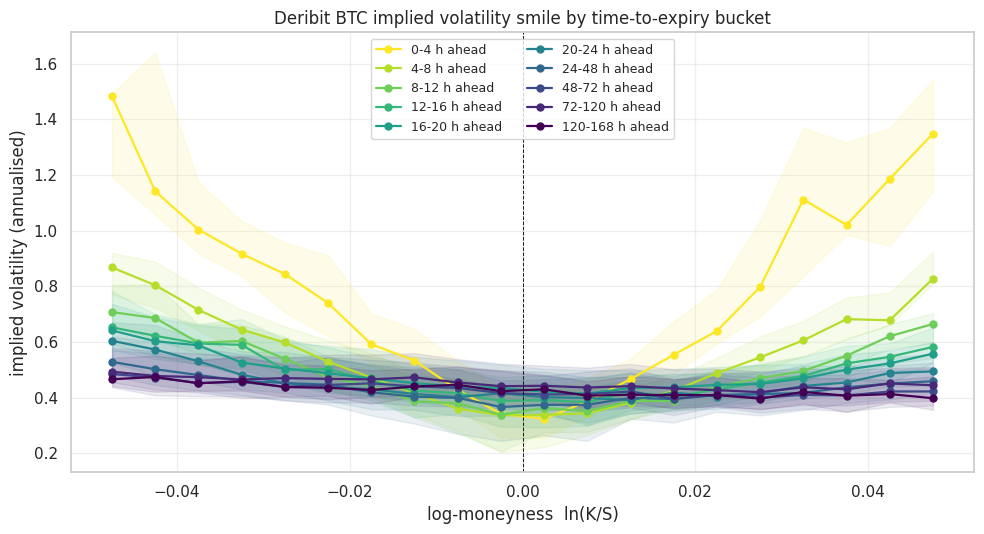

In [4]:
M_BINS = np.linspace(-0.05, 0.05, 21)

short["m_bin"] = pd.cut(short["log_moneyness"], M_BINS)
deribit_smile = (short.groupby(["ttr_bucket", "m_bin"], observed=True)["iv_frac"]
                       .agg(median="median",
                            q25=lambda s: s.quantile(0.25),
                            q75=lambda s: s.quantile(0.75),
                            n="count")
                       .reset_index())
deribit_smile["m_mid"] = deribit_smile["m_bin"].apply(lambda b: b.mid).astype(float)
deribit_smile = deribit_smile[deribit_smile["n"] >= 20]

cmap = plt.get_cmap("viridis_r")
ttr_mid = {lab: (lo + hi) / 2.0
           for lab, lo, hi in zip(BUCKET_LABELS, BUCKET_EDGES[:-1], BUCKET_EDGES[1:])}

fig, ax = plt.subplots(figsize=(10, 5.5))
for i, label in enumerate(BUCKET_LABELS):
    sub = deribit_smile[deribit_smile["ttr_bucket"] == label].sort_values("m_mid")
    if sub.empty:
        continue
    c = cmap(i / max(len(BUCKET_LABELS) - 1, 1))
    ax.plot(sub["m_mid"], sub["median"], "-o", color=c, lw=1.6, ms=5,
            label=f"{label} ahead")
    ax.fill_between(sub["m_mid"], sub["q25"], sub["q75"], color=c, alpha=0.10)
ax.axvline(0, color="k", lw=0.7, ls="--")
ax.set_xlabel("log-moneyness  ln(K/S)")
ax.set_ylabel("implied volatility (annualised)")
ax.set_title("Deribit BTC implied volatility smile by time-to-expiry bucket")
ax.legend(ncol=2, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Comparison with the Polymarket smile

Both smiles use the same horizon buckets and the same log-moneyness binning.
We plot the two markets in 2×3 panels — one panel per bucket — so the shapes
can be compared at every horizon.


Polymarket smile: 5,955 (date, strike) IV points, 10 buckets


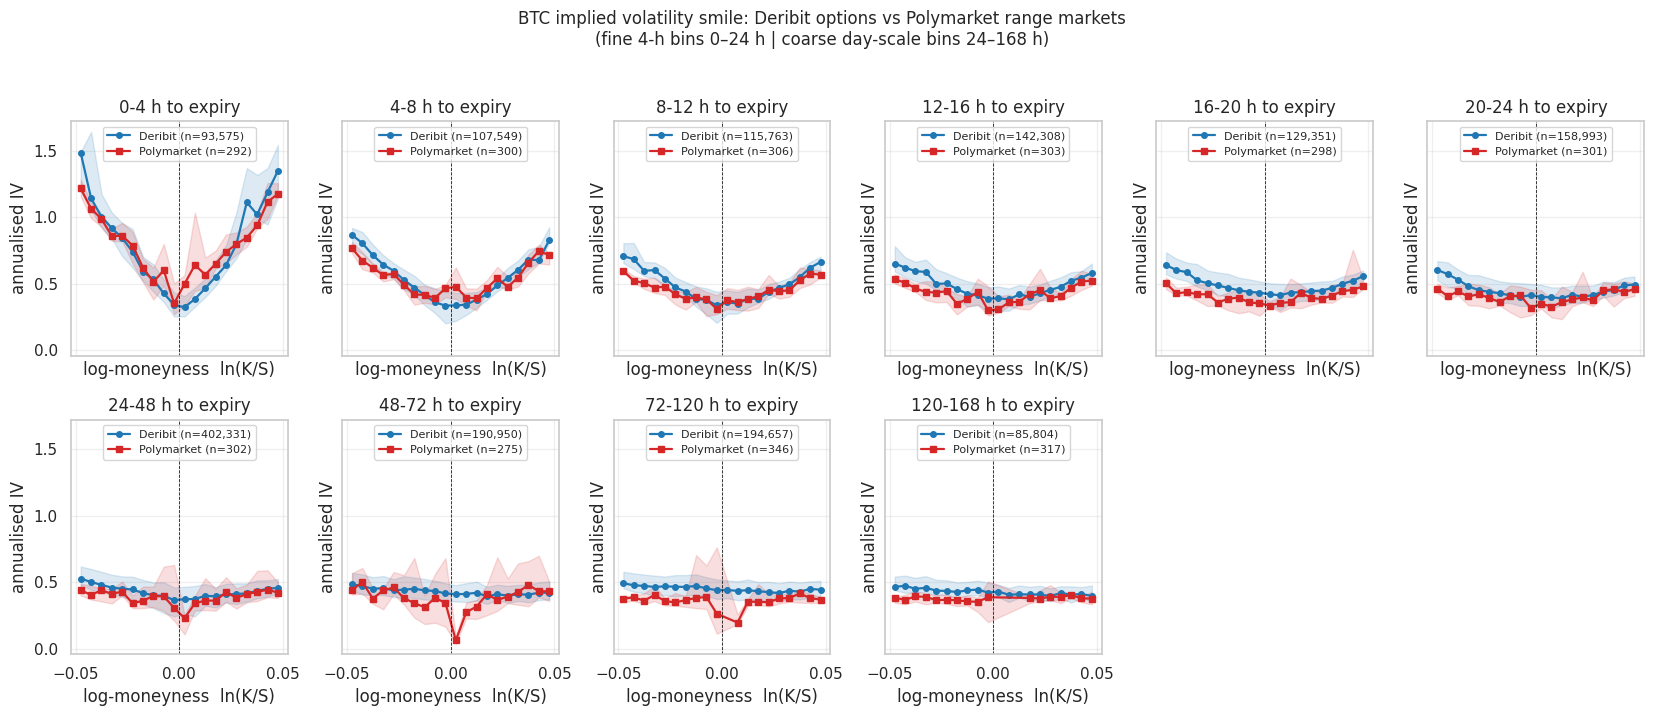

In [5]:
poly_smile = pd.read_parquet(POLY_SMILE_PARQUET)
print(f"Polymarket smile: {len(poly_smile):,} (date, strike) IV points, "
      f"{poly_smile['ttr_label'].nunique()} buckets")

poly_smile["m_bin"] = pd.cut(poly_smile["log_moneyness"], M_BINS)
poly_agg = (poly_smile.groupby(["ttr_label", "m_bin"], observed=True)["sigma_bs"]
                       .agg(median="median",
                            q25=lambda s: s.quantile(0.25),
                            q75=lambda s: s.quantile(0.75),
                            n="count")
                       .reset_index())
poly_agg["m_mid"] = poly_agg["m_bin"].apply(lambda b: b.mid).astype(float)
poly_agg = poly_agg[poly_agg["n"] >= 5]

# Layout: first row = fine 4-h bins (last 24 h), second row = coarse bins
n_buckets = len(BUCKET_LABELS)
ncols = min(6, n_buckets)
nrows = (n_buckets + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.8, nrows * 3.5),
                         sharex=True, sharey=True)
axes_flat = axes.ravel() if n_buckets > 1 else [axes]
# Hide unused panels
for ax in axes_flat[n_buckets:]:
    ax.set_visible(False)
for ax, label in zip(axes_flat, BUCKET_LABELS):
    d_sub = deribit_smile[deribit_smile["ttr_bucket"] == label].sort_values("m_mid")
    p_sub = poly_agg[poly_agg["ttr_label"] == label].sort_values("m_mid")
    if not d_sub.empty:
        ax.plot(d_sub["m_mid"], d_sub["median"], "-o", color="#1f77b4",
                label=f"Deribit (n={int(d_sub['n'].sum()):,})", lw=1.6, ms=4)
        ax.fill_between(d_sub["m_mid"], d_sub["q25"], d_sub["q75"],
                        color="#1f77b4", alpha=0.15)
    if not p_sub.empty:
        ax.plot(p_sub["m_mid"], p_sub["median"], "-s", color="#d62728",
                label=f"Polymarket (n={int(p_sub['n'].sum()):,})", lw=1.6, ms=4)
        ax.fill_between(p_sub["m_mid"], p_sub["q25"], p_sub["q75"],
                        color="#d62728", alpha=0.15)
    ax.axvline(0, color="k", lw=0.6, ls="--")
    ax.set_title(f"{label} to expiry")
    ax.set_xlabel("log-moneyness  ln(K/S)")
    ax.set_ylabel("annualised IV")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="upper center")
fig.suptitle("BTC implied volatility smile: Deribit options vs Polymarket range markets\n"
             "(fine 4-h bins 0–24 h | coarse day-scale bins 24–168 h)",
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


### Reading the comparison

* **The two markets agree on the shape of the smile at every horizon.**  In
  each of the six panels the Deribit and Polymarket curves are convex,
  approximately symmetric around $\ln(K/S)=0$ and have minima very close to
  the at-the-money strike.
* **The 0–4 h panel is the most striking match.**  Both curves explode in
  exactly the same way — wing IV $\approx 1.2$–$1.5$ vs ATM $\approx 0.35$ —
  even though Deribit aggregates $\sim 94$k trades and Polymarket only
  $\sim 290$ band-quotes.  A retail prediction market with **no replication
  argument** is producing the same short-dated tail premium as a professional
  listed-options market.
* **Polymarket sits slightly *below* Deribit in the 12–24 h buckets** by
  roughly 5–10 vol points across all strikes.  Two interpretations:
  1. *Variance risk premium.*  Deribit dealers charge an extra premium for
     warehousing volatility risk that retail Polymarket participants do not.
  2. *Funding/liquidity discount.*  Polymarket capital is locked from purchase
     to resolution with no funding rebate, so all-in fair prices are
     mechanically a touch lower than the Deribit risk-neutral measure.
* **Deribit shows a mild call-skew** (right wing slightly higher than left) at
  most horizons — the well-known "BTC has more upside vol than downside" pattern
  during bullish regimes.  Polymarket does **not** exhibit this skew, again
  consistent with retail traders pricing moves symmetrically rather than the
  professional flow that dominates Deribit.
* **Bottom line.**  Polymarket's daily BTC range markets, viewed as a
  digital-call book, deliver an implied-vol surface that is qualitatively
  *and* quantitatively comparable to Deribit's listed BTC options surface on
  the same horizon — with small, interpretable systematic differences (lower
  level, no call-skew).
